# 13. LaMa Difference and Error Map Diagnostics

This notebook generates diagnostic difference and error-map figures for the LaMa restoration baseline on the controlled 50-painting subset.

The notebook reuses the same error-map framework previously applied to the OpenCV Telea baseline, but applies it to LaMa restored outputs.

The generated diagnostics compare:

- clean reference image,
- binary damage mask,
- damaged input image,
- LaMa restored image,
- clean-vs-damaged absolute error,
- clean-vs-restored absolute error,
- signed restoration improvement,
- masked signed restoration improvement.

The purpose is not to judge restoration quality from images alone. These figures provide spatial diagnostic evidence that complements the classical metric results from Notebook 12.

## Setup

This notebook assumes that the following previous stages are complete:

1. cleaned 50-painting metadata,
2. processed clean images,
3. controlled masks,
4. damaged image creation,
5. LaMa restoration generation,
6. LaMa classical metric computation.

The main LaMa restoration metadata file is:

`data/processed/metadata/metadata_restored_lama.csv`

The main LaMa classical metric file is:

`outputs/metrics/classical_metrics_lama_50.csv`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.error_maps import (
    generate_error_map_figures_for_cases,
    validate_error_map_manifest,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

lama_metadata_path = processed_metadata_dir / "metadata_restored_lama.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

classical_metrics_path = metrics_dir / "classical_metrics_lama_50.csv"
strongest_cases_path = metrics_dir / "lama_strongest_masked_region_cases_50.csv"
weakest_cases_path = metrics_dir / "lama_weakest_masked_region_cases_50.csv"

error_maps_dir = figures_dir / "error_maps" / "lama"
selected_error_maps_dir = error_maps_dir / "selected_cases"
all_error_maps_dir = error_maps_dir / "all_cases"

selected_manifest_path = metrics_dir / "error_map_manifest_selected_lama_50.csv"
all_manifest_path = metrics_dir / "error_map_manifest_all_lama_50.csv"
selected_summary_path = metrics_dir / "error_map_summary_selected_lama_50.csv"
all_summary_path = metrics_dir / "error_map_summary_all_lama_50.csv"

model_name = "lama"

print("LaMa metadata:", lama_metadata_path)
print("Classical metrics:", classical_metrics_path)
print("Selected error maps dir:", selected_error_maps_dir)
print("All error maps dir:", all_error_maps_dir)

LaMa metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_lama.csv
Classical metrics: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_lama_50.csv
Selected error maps dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\lama\selected_cases
All error maps dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\lama\all_cases


In [3]:
required_input_paths = [
    lama_metadata_path,
    processed_clean_metadata_path,
    classical_metrics_path,
    strongest_cases_path,
    weakest_cases_path,
]

for input_path in required_input_paths:
    if not input_path.exists():
        raise FileNotFoundError(f"Missing required input: {input_path}")

lama_restored_df = pd.read_csv(lama_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)
classical_metrics_df = pd.read_csv(classical_metrics_path)
strongest_cases_df = pd.read_csv(strongest_cases_path)
weakest_cases_df = pd.read_csv(weakest_cases_path)

print("LaMa restored metadata shape:", lama_restored_df.shape)
print("Processed clean metadata shape:", processed_clean_df.shape)
print("LaMa classical metrics shape:", classical_metrics_df.shape)
print("Strongest cases shape:", strongest_cases_df.shape)
print("Weakest cases shape:", weakest_cases_df.shape)

display(lama_restored_df.head())

LaMa restored metadata shape: (250, 32)
Processed clean metadata shape: (50, 43)
LaMa classical metrics shape: (900, 30)
Strongest cases shape: (20, 30)
Weakest cases shape: (20, 30)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,model_name,restoration_method,inference_mode,restored_filename,restored_path,device,batch_runtime_seconds,restored_width,restored_height,restored_mode
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_loss_large_restored_lama.png,data/processed/restored/lama/p001_loss_large_r...,cuda,302.614275,768,768,RGB
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_loss_small_restored_lama.png,data/processed/restored/lama/p001_loss_small_r...,cuda,302.614275,768,768,RGB
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_mixed_damage_restored_lama.png,data/processed/restored/lama/p001_mixed_damage...,cuda,302.614275,768,768,RGB
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_scratch_thin_restored_lama.png,data/processed/restored/lama/p001_scratch_thin...,cuda,302.614275,768,768,RGB
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,zero_control_copy,copied_zero_control,p001_zero_control_restored_lama.png,data/processed/restored/lama/p001_zero_control...,none,0.000000,768,768,RGB


In [4]:
metadata_lookup_columns = [
    "painting_id",
    "category",
    "title",
]

missing_lookup_columns = [
    column for column in metadata_lookup_columns
    if column not in processed_clean_df.columns
]

if missing_lookup_columns:
    raise ValueError(
        f"Processed clean metadata missing lookup columns: {missing_lookup_columns}"
    )

metadata_lookup_df = (
    processed_clean_df[metadata_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

if metadata_lookup_df["category"].isna().any():
    raise ValueError("Processed clean metadata contains missing category labels.")

lama_cases_df = lama_restored_df.copy()

# Remove stale or broken display metadata before merging clean labels.
lama_cases_df = lama_cases_df.drop(
    columns=[column for column in ["category", "title"] if column in lama_cases_df.columns],
    errors="ignore",
)

lama_cases_df = lama_cases_df.merge(
    metadata_lookup_df,
    on="painting_id",
    how="left",
)

missing_after_merge = lama_cases_df[["category", "title"]].isna().sum()

print("Missing values after metadata enrichment:")
display(missing_after_merge)

if lama_cases_df["category"].isna().any():
    display(lama_cases_df[lama_cases_df["category"].isna()].head(20))
    raise ValueError("LaMa metadata enrichment failed: missing category labels.")

print("LaMa enriched metadata shape:", lama_cases_df.shape)

print("\nCategory counts by restoration rows:")
display(lama_cases_df["category"].value_counts().sort_index())

print("\nMask type counts:")
display(lama_cases_df["mask_type"].value_counts().sort_index())

display(
    lama_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "model_name",
            "status",
            "restored_path",
        ]
    ].head()
)

Missing values after metadata enrichment:


category    0
title       0
dtype: int64

LaMa enriched metadata shape: (250, 34)

Category counts by restoration rows:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_type,model_name,status,restored_path
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,lama,ok,data/processed/restored/lama/p001_loss_large_r...
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,lama,ok,data/processed/restored/lama/p001_loss_small_r...
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,lama,ok,data/processed/restored/lama/p001_mixed_damage...
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,lama,ok,data/processed/restored/lama/p001_scratch_thin...
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,lama,ok,data/processed/restored/lama/p001_zero_control...


In [5]:
required_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "mask_path",
    "damaged_path",
    "restored_path",
    "status",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in lama_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"LaMa cases metadata missing columns: {missing_case_columns}")

if len(lama_cases_df) != 250:
    raise ValueError(f"Expected 250 LaMa cases, found {len(lama_cases_df)}.")

if lama_cases_df["case_id"].duplicated().any():
    duplicate_case_ids = lama_cases_df.loc[
        lama_cases_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_case_ids[:10]}")

if (lama_cases_df["status"] != "ok").any():
    display(lama_cases_df[lama_cases_df["status"] != "ok"])
    raise ValueError("LaMa cases contain non-ok rows.")

if set(lama_cases_df["model_name"].unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {lama_cases_df['model_name'].unique()}"
    )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = lama_cases_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_category_counts = lama_cases_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

lama_cases_abs_df = lama_cases_df.copy()

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    lama_cases_abs_df[path_column] = lama_cases_abs_df[path_column].apply(
        lambda value: str(PROJECT_ROOT / value) if not Path(value).is_absolute() else value
    )

missing_files = []

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    missing_column_files = [
        path for path in lama_cases_abs_df[path_column]
        if not Path(path).exists()
    ]

    if missing_column_files:
        missing_files.extend(missing_column_files[:10])

if missing_files:
    raise FileNotFoundError(f"Missing image/mask files: {missing_files[:10]}")

print("LaMa metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
LaMa metadata gates passed.


## Selected diagnostic cases

The selected error-map figures are chosen from metric-driven groups:

1. strongest masked-region MSE improvement cases,
2. weakest masked-region MSE improvement cases,
3. one representative `mixed_damage` case per painting category,
4. one zero-control sanity case.

These selections are diagnostic examples, not final qualitative rankings.

In [6]:
selected_case_records = []

# Strongest masked-region MSE improvement cases.
for case_id in strongest_cases_df["case_id"].head(5).tolist():
    selected_case_records.append(
        {
            "case_id": case_id,
            "selection_group": "strongest_masked_mse_improvement",
        }
    )

# Weakest masked-region MSE improvement cases.
for case_id in weakest_cases_df["case_id"].head(5).tolist():
    selected_case_records.append(
        {
            "case_id": case_id,
            "selection_group": "weakest_masked_mse_improvement",
        }
    )

# One representative mixed_damage case per category, using median-ish masked-region MSE improvement.
masked_mixed_damage_metrics_df = classical_metrics_df[
    (classical_metrics_df["evaluation_region"] == "masked_region")
    & (classical_metrics_df["mask_type"] == "mixed_damage")
    & (classical_metrics_df["status"] == "ok")
].copy()

if masked_mixed_damage_metrics_df.empty:
    raise ValueError("No masked-region mixed_damage metric rows found.")

for category in sorted(masked_mixed_damage_metrics_df["category"].dropna().unique()):
    category_df = (
        masked_mixed_damage_metrics_df[
            masked_mixed_damage_metrics_df["category"] == category
        ]
        .sort_values("mse_improvement")
        .reset_index(drop=True)
    )

    median_index = len(category_df) // 2
    case_id = category_df.loc[median_index, "case_id"]

    selected_case_records.append(
        {
            "case_id": case_id,
            "selection_group": f"representative_mixed_damage_{category}",
        }
    )

# Add one zero-control sanity case.
zero_control_case_id = (
    lama_cases_abs_df[lama_cases_abs_df["mask_type"] == "zero_control"]
    .sort_values("case_id")
    ["case_id"]
    .iloc[0]
)

selected_case_records.append(
    {
        "case_id": zero_control_case_id,
        "selection_group": "zero_control_sanity_check",
    }
)

selected_cases_raw_df = pd.DataFrame(selected_case_records)

# De-duplicate case IDs while preserving the first selection group.
selected_cases_raw_df = (
    selected_cases_raw_df
    .drop_duplicates(subset=["case_id"], keep="first")
    .reset_index(drop=True)
)

selected_lama_cases_df = lama_cases_abs_df.merge(
    selected_cases_raw_df,
    on="case_id",
    how="inner",
)

# Preserve selected order.
selected_lama_cases_df = (
    selected_lama_cases_df
    .set_index("case_id")
    .loc[selected_cases_raw_df["case_id"]]
    .reset_index()
)

print("Selected LaMa diagnostic cases:", len(selected_lama_cases_df))

display(
    selected_lama_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "selection_group",
            "model_name",
        ]
    ]
)

Selected LaMa diagnostic cases: 16


,case_id,painting_id,category,title,mask_type,selection_group,model_name
0,p006_loss_large,p006,portrait_figure,Boy with a Sword,loss_large,strongest_masked_mse_improvement,lama
1,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,mixed_damage,strongest_masked_mse_improvement,lama
2,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,strongest_masked_mse_improvement,lama
3,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,scratch_thin,strongest_masked_mse_improvement,lama
4,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,strongest_masked_mse_improvement,lama
5,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,weakest_masked_mse_improvement,lama
6,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,weakest_masked_mse_improvement,lama
7,p032_mixed_damage,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,mixed_damage,weakest_masked_mse_improvement,lama
8,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,weakest_masked_mse_improvement,lama
9,p020_loss_small,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_small,weakest_masked_mse_improvement,lama


In [7]:
selected_error_map_manifest_df = generate_error_map_figures_for_cases(
    cases_metadata=selected_lama_cases_df,
    output_dir=selected_error_maps_dir,
    selection_group_column="selection_group",
    show=False,
    dpi=150,
    progress_every=5,
)

selected_error_map_manifest_df.to_csv(selected_manifest_path, index=False)

print("Selected error-map manifest shape:", selected_error_map_manifest_df.shape)
print("Saved selected manifest:")
print(selected_manifest_path)

display(selected_error_map_manifest_df.head())

Starting error-map generation for 16 cases...
Output directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\lama\selected_cases
Processed 1/16 cases...
Processed 5/16 cases...
Processed 10/16 cases...
Processed 15/16 cases...
Processed 16/16 cases...
Error-map generation finished.
Selected error-map manifest shape: (16, 29)
Saved selected manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_manifest_selected_lama_50.csv


,case_id,painting_id,category,title,mask_id,mask_type,model_name,selection_group,figure_filename,figure_path,...,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked,status,issue
0,p006_loss_large,p006,portrait_figure,Boy with a Sword,p006_loss_large,loss_large,lama,strongest_masked_mse_improvement,p006_loss_large_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,227.927582,6.756586,221.170990,0,51891,0,0.0,100.0,ok,
1,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,p006_mixed_damage,mixed_damage,lama,strongest_masked_mse_improvement,p006_mixed_damage_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,227.115158,3.134551,223.980576,0,44236,0,0.0,100.0,ok,
2,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),p002_loss_large,loss_large,lama,strongest_masked_mse_improvement,p002_loss_large_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,225.618668,6.456553,219.162109,0,49705,0,0.0,100.0,ok,
3,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,p006_scratch_thin,scratch_thin,lama,strongest_masked_mse_improvement,p006_scratch_thin_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,224.160110,2.823565,221.336548,0,13053,0,0.0,100.0,ok,
4,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,lama,strongest_masked_mse_improvement,p001_mixed_damage_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,224.467407,8.570448,215.896942,0,44392,0,0.0,100.0,ok,


In [8]:
selected_validation_df = validate_error_map_manifest(
    selected_error_map_manifest_df,
    expected_rows=len(selected_lama_cases_df),
)

print("Selected manifest validation:")
display(selected_validation_df)

if not selected_validation_df["passed"].all():
    raise ValueError("Selected LaMa error-map manifest validation failed.")

if (selected_error_map_manifest_df["status"] != "ok").any():
    display(selected_error_map_manifest_df[selected_error_map_manifest_df["status"] != "ok"])
    raise ValueError("Selected LaMa error-map generation contains non-ok rows.")

print("Selected LaMa error-map validation passed.")

Selected manifest validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 16, found 16."
2,status_ok,True,Rows with non-ok status: 0.
3,figures_exist,True,Missing figure files: 0.


Selected LaMa error-map validation passed.


In [9]:
selected_summary_columns = [
    "selection_group",
    "mask_type",
    "category",
    "masked_pixel_count",
    "damaged_error_mean_masked",
    "restored_error_mean_masked",
    "improvement_mean_masked",
    "positive_improvement_percentage_masked",
    "negative_improvement_percentage_masked",
]

selected_error_summary_df = selected_error_map_manifest_df[
    selected_summary_columns
].copy()

selected_error_summary_df.to_csv(selected_summary_path, index=False)

print("Saved selected error-map summary:")
print(selected_summary_path)

display(
    selected_error_summary_df.sort_values(
        ["selection_group", "category", "mask_type"]
    )
)

Saved selected error-map summary:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_summary_selected_lama_50.csv


,selection_group,mask_type,category,masked_pixel_count,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,positive_improvement_percentage_masked,negative_improvement_percentage_masked
10,representative_mixed_damage_abstraction_surrea...,mixed_damage,abstraction_surrealism,44266,146.752151,18.767775,127.984390,98.947273,1.045949
11,representative_mixed_damage_architecture_struc...,mixed_damage,architecture_structured,50041,150.006699,11.268826,138.737885,99.990008,0.009992
12,representative_mixed_damage_high_texture_brush...,mixed_damage,high_texture_brushwork,46861,173.280762,12.412881,160.867889,99.767397,0.228335
13,representative_mixed_damage_landscape_natural,mixed_damage,landscape_natural,44361,150.509262,7.973408,142.535873,100.000000,0.000000
14,representative_mixed_damage_portrait_figure,mixed_damage,portrait_figure,38316,189.624557,18.676594,170.947952,99.498904,0.495876
0,strongest_masked_mse_improvement,loss_large,portrait_figure,51891,227.927582,6.756586,221.170990,100.000000,0.000000
2,strongest_masked_mse_improvement,loss_large,portrait_figure,49705,225.618668,6.456553,219.162109,100.000000,0.000000
1,strongest_masked_mse_improvement,mixed_damage,portrait_figure,44236,227.115158,3.134551,223.980576,100.000000,0.000000
4,strongest_masked_mse_improvement,mixed_damage,portrait_figure,44392,224.467407,8.570448,215.896942,100.000000,0.000000
3,strongest_masked_mse_improvement,scratch_thin,portrait_figure,13053,224.160110,2.823565,221.336548,100.000000,0.000000


Displaying one figure per selection group:


,selection_group,case_id,category,mask_type,figure_path
0,representative_mixed_damage_abstraction_surrea...,p034_mixed_damage,abstraction_surrealism,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
1,representative_mixed_damage_architecture_struc...,p021_mixed_damage,architecture_structured,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
2,representative_mixed_damage_high_texture_brush...,p049_mixed_damage,high_texture_brushwork,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
3,representative_mixed_damage_landscape_natural,p011_mixed_damage,landscape_natural,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
4,representative_mixed_damage_portrait_figure,p005_mixed_damage,portrait_figure,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
5,strongest_masked_mse_improvement,p001_mixed_damage,portrait_figure,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...
6,weakest_masked_mse_improvement,p020_loss_small,landscape_natural,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...
7,zero_control_sanity_check,p001_zero_control,portrait_figure,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...


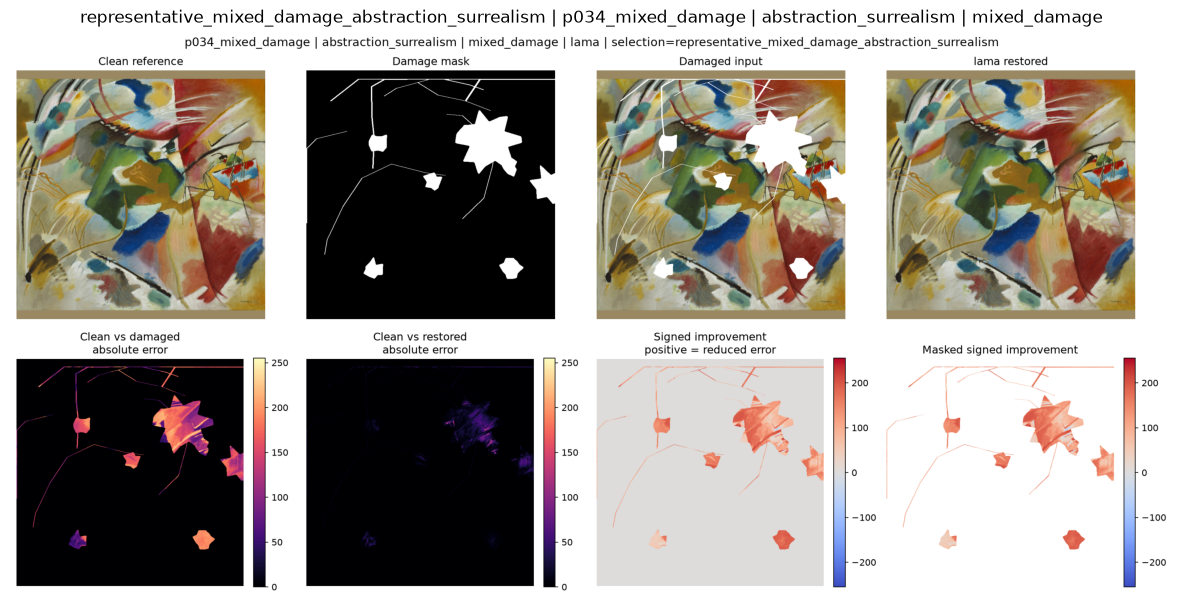

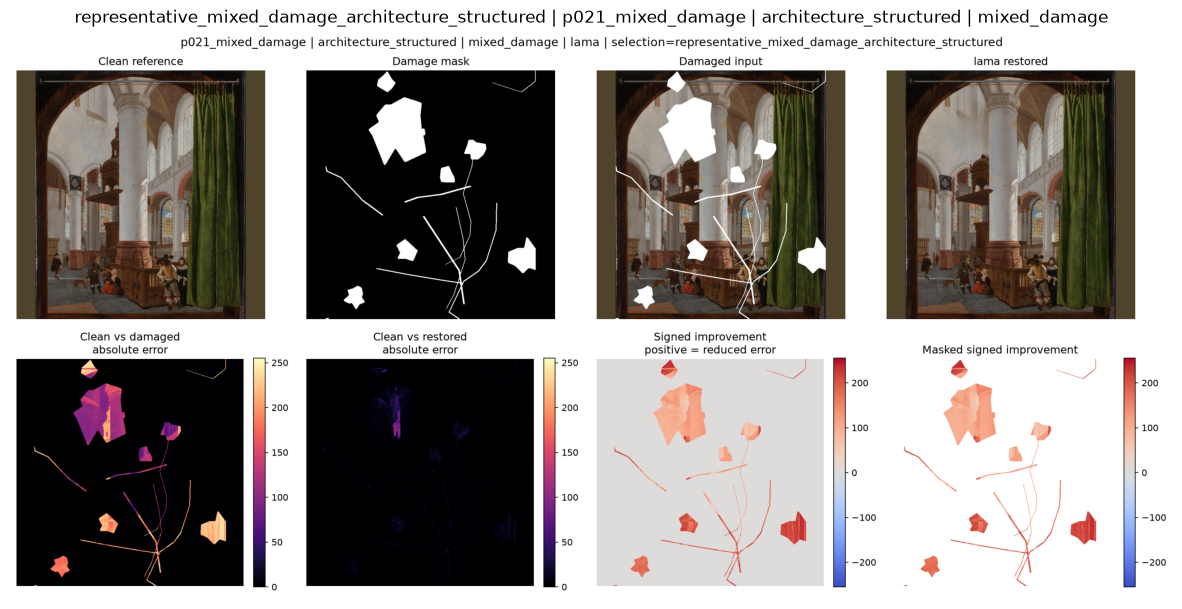

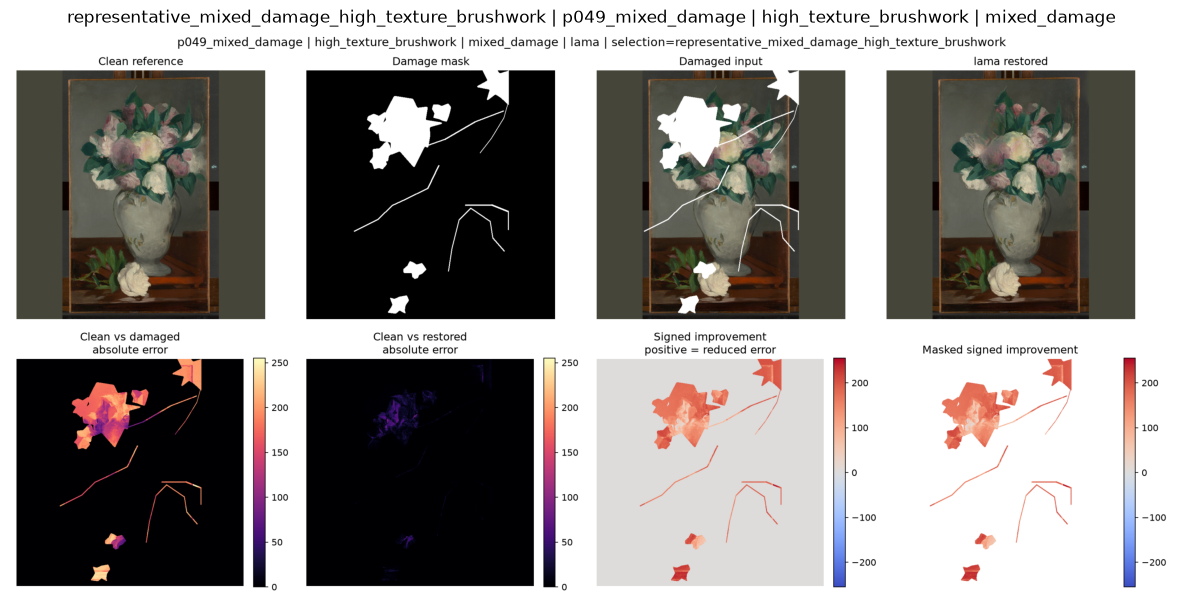

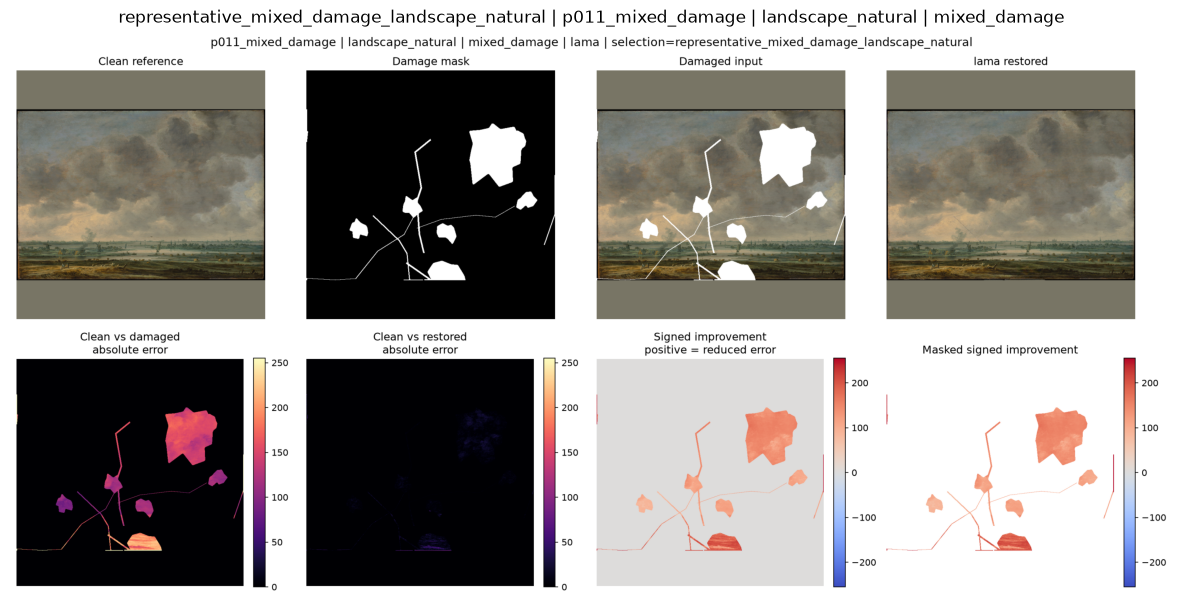

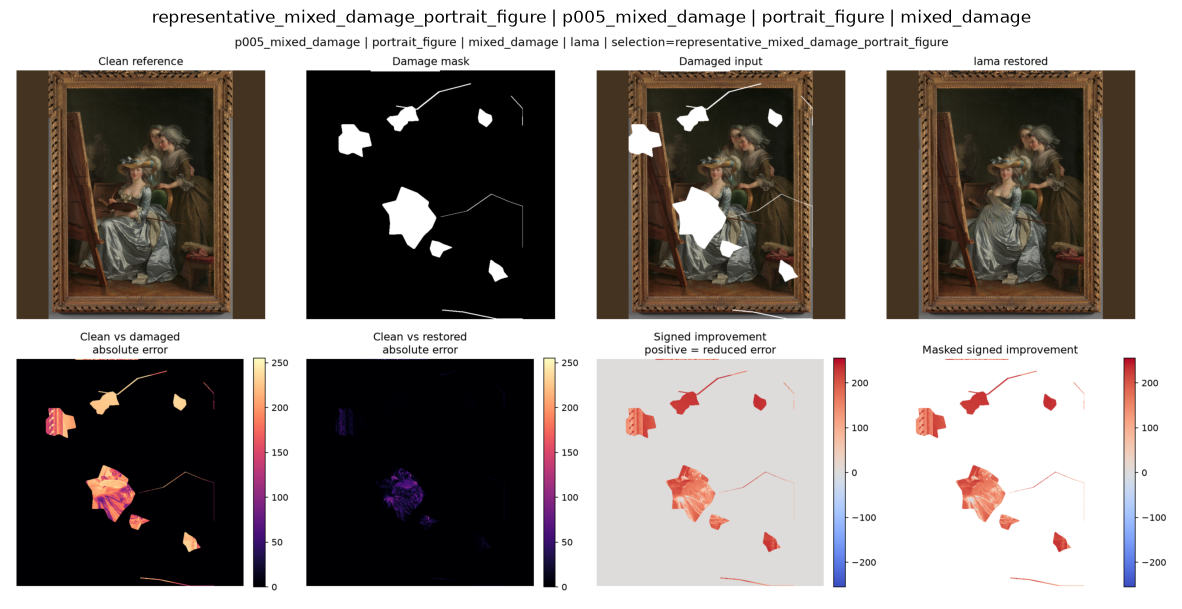

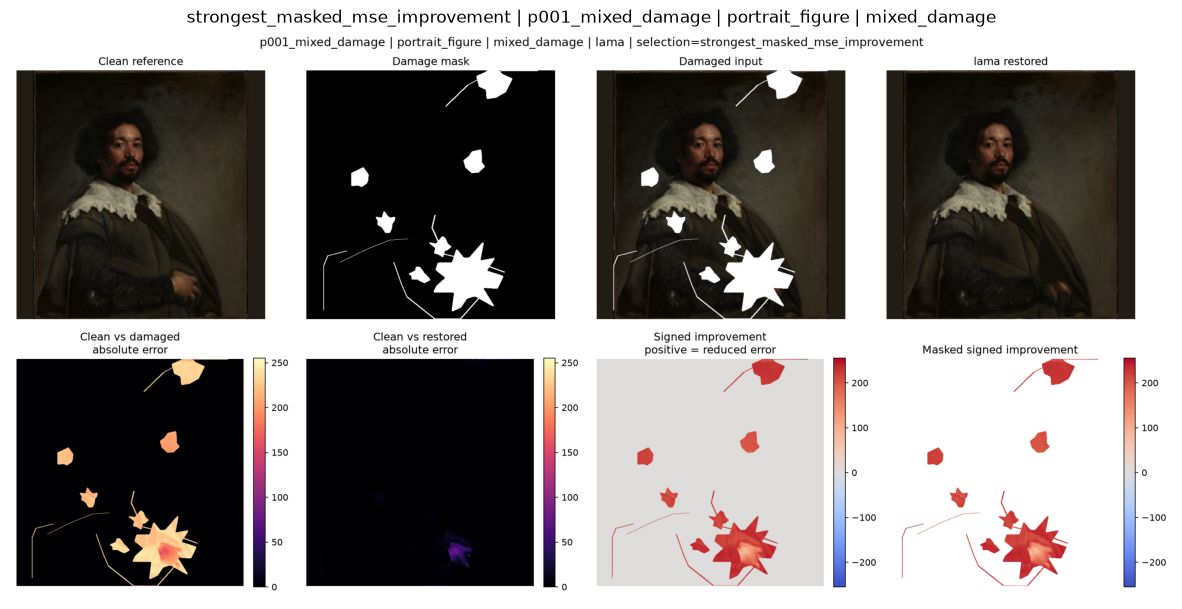

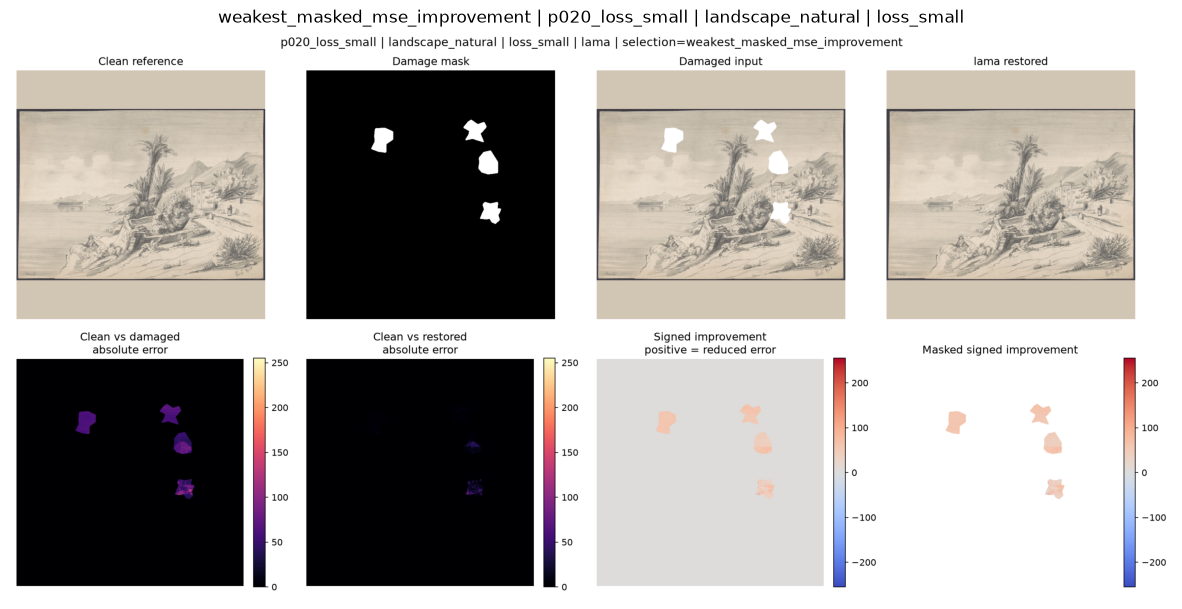

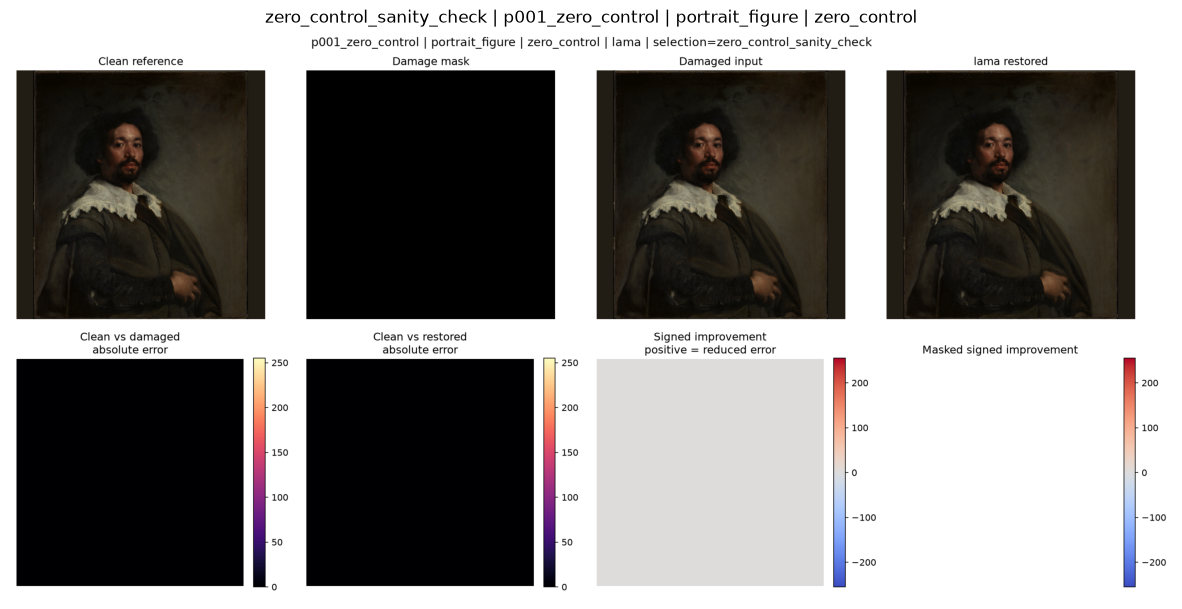

In [10]:
selection_group_examples = (
    selected_error_map_manifest_df
    .sort_values(["selection_group", "case_id"])
    .groupby("selection_group", as_index=False)
    .first()
)

print("Displaying one figure per selection group:")
display(
    selection_group_examples[
        [
            "selection_group",
            "case_id",
            "category",
            "mask_type",
            "figure_path",
        ]
    ]
)

for _, row in selection_group_examples.iterrows():
    figure_path = Path(row["figure_path"])

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing figure: {figure_path}")

    image = Image.open(figure_path)

    plt.figure(figsize=(15, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{row['selection_group']} | {row['case_id']} | "
        f"{row['category']} | {row['mask_type']}"
    )
    plt.show()

Displaying strongest and weakest masked-region improvement examples:


,selection_group,case_id,category,mask_type,improvement_mean_masked,positive_improvement_percentage_masked,negative_improvement_percentage_masked,figure_path
0,strongest_masked_mse_improvement,p006_loss_large,portrait_figure,loss_large,221.170990,100.000000,0.000000,D:\Masters\FH\Thesis\painting-restoration-eval...
1,strongest_masked_mse_improvement,p006_mixed_damage,portrait_figure,mixed_damage,223.980576,100.000000,0.000000,D:\Masters\FH\Thesis\painting-restoration-eval...
2,weakest_masked_mse_improvement,p036_loss_large,abstraction_surrealism,loss_large,23.783266,89.284397,10.671122,D:\Masters\FH\Thesis\painting-restoration-eval...
3,weakest_masked_mse_improvement,p036_scratch_thin,abstraction_surrealism,scratch_thin,26.960783,99.928083,0.071917,D:\Masters\FH\Thesis\painting-restoration-eval...


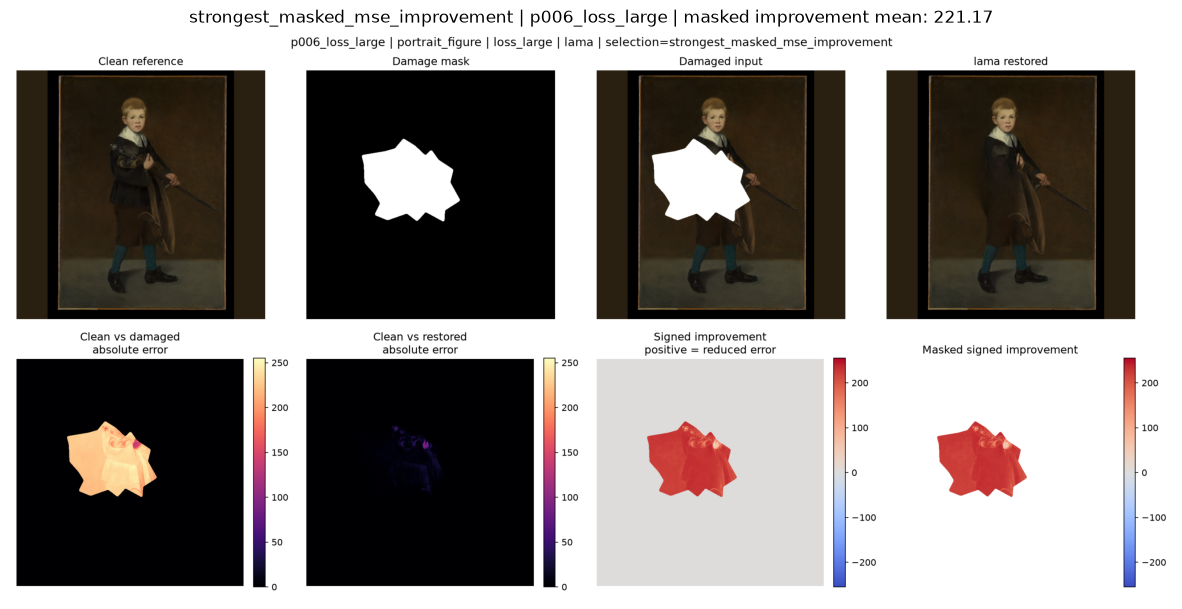

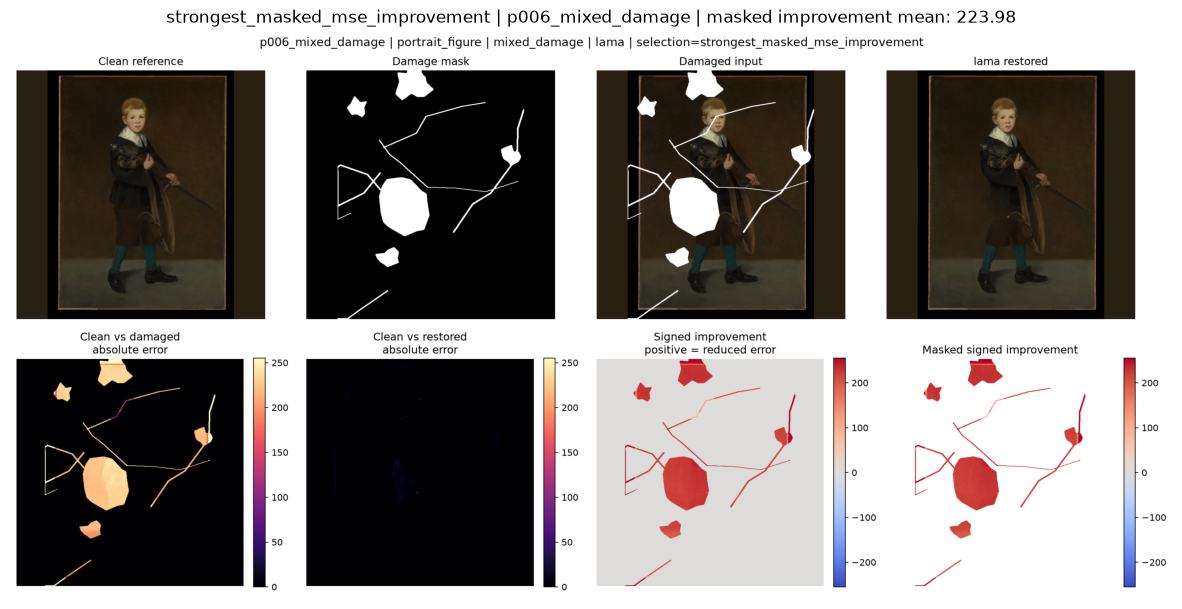

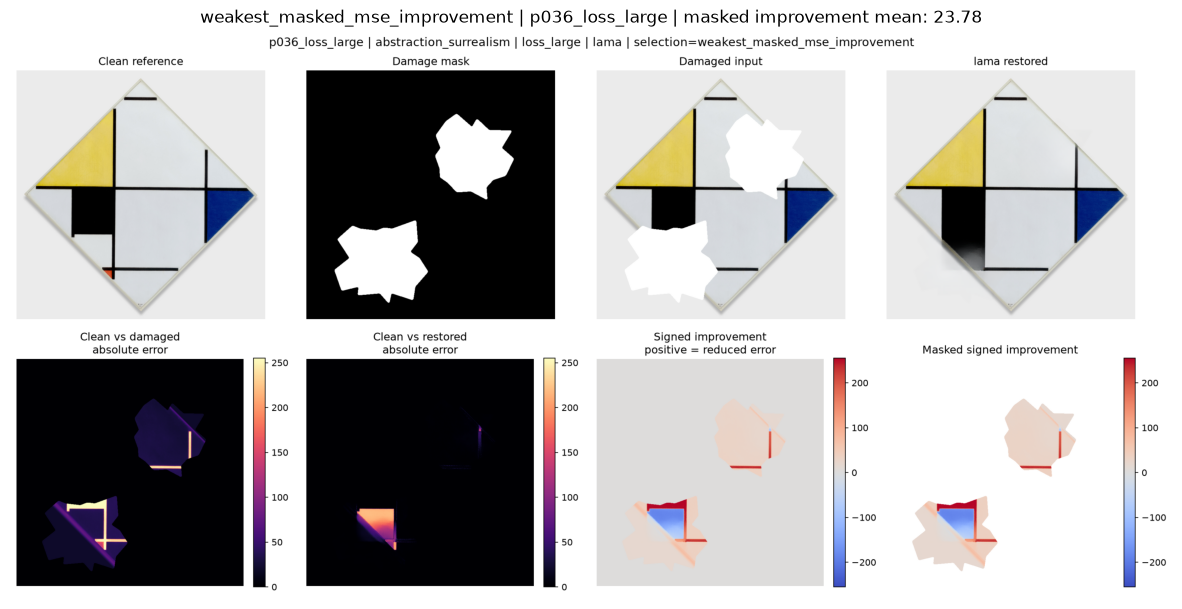

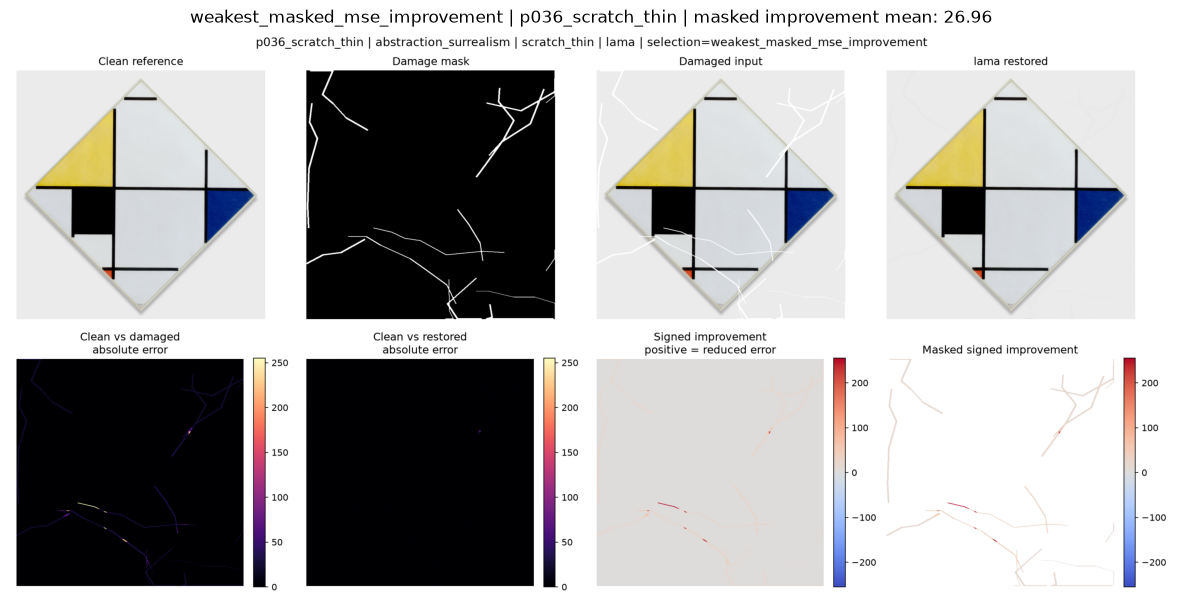

In [11]:
strongest_example_df = selected_error_map_manifest_df[
    selected_error_map_manifest_df["selection_group"] == "strongest_masked_mse_improvement"
].head(2)

weakest_example_df = selected_error_map_manifest_df[
    selected_error_map_manifest_df["selection_group"] == "weakest_masked_mse_improvement"
].head(2)

example_display_df = pd.concat(
    [strongest_example_df, weakest_example_df],
    ignore_index=True,
)

print("Displaying strongest and weakest masked-region improvement examples:")
display(
    example_display_df[
        [
            "selection_group",
            "case_id",
            "category",
            "mask_type",
            "improvement_mean_masked",
            "positive_improvement_percentage_masked",
            "negative_improvement_percentage_masked",
            "figure_path",
        ]
    ]
)

for _, row in example_display_df.iterrows():
    figure_path = Path(row["figure_path"])

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing figure: {figure_path}")

    image = Image.open(figure_path)

    plt.figure(figsize=(15, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{row['selection_group']} | {row['case_id']} | "
        f"masked improvement mean: {row['improvement_mean_masked']:.2f}"
    )
    plt.show()

## Full LaMa error-map generation

The selected cases above are used for quick visual inspection.

The next cell generates diagnostic error-map figures for all 250 LaMa restoration cases, including zero-control cases. Zero-control cases are useful sanity checks because the damaged input and restored output should remain identical.

In [13]:
all_lama_cases_df = lama_cases_abs_df.copy()
all_lama_cases_df["selection_group"] = "all_lama_cases"

all_error_map_manifest_df = generate_error_map_figures_for_cases(
    cases_metadata=all_lama_cases_df,
    output_dir=all_error_maps_dir,
    selection_group_column="selection_group",
    show=False,
    dpi=150,
    progress_every=5,
)

all_error_map_manifest_df.to_csv(all_manifest_path, index=False)

print("All-case error-map manifest shape:", all_error_map_manifest_df.shape)
print("Saved all-case manifest:")
print(all_manifest_path)

display(all_error_map_manifest_df.head())

Starting error-map generation for 250 cases...
Output directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\lama\all_cases
Processed 1/250 cases...
Processed 5/250 cases...
Processed 10/250 cases...
Processed 15/250 cases...
Processed 20/250 cases...
Processed 25/250 cases...
Processed 30/250 cases...
Processed 35/250 cases...
Processed 40/250 cases...
Processed 45/250 cases...
Processed 50/250 cases...
Processed 55/250 cases...
Processed 60/250 cases...
Processed 65/250 cases...
Processed 70/250 cases...
Processed 75/250 cases...
Processed 80/250 cases...
Processed 85/250 cases...
Processed 90/250 cases...
Processed 95/250 cases...
Processed 100/250 cases...
Processed 105/250 cases...
Processed 110/250 cases...
Processed 115/250 cases...
Processed 120/250 cases...
Processed 125/250 cases...
Processed 130/250 cases...
Processed 135/250 cases...
Processed 140/250 cases...
Processed 145/250 cases...
Processed 150/250 cases...
Processed 155/250 cases...
Proc

,case_id,painting_id,category,title,mask_id,mask_type,model_name,selection_group,figure_filename,figure_path,...,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,all_lama_cases,p001_loss_large_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,219.804596,9.788516,210.016098,84,67156,2,0.124922,99.872104,ok,
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,all_lama_cases,p001_loss_small_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,216.069473,2.889164,213.180283,0,24198,0,0.000000,100.000000,ok,
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,lama,all_lama_cases,p001_mixed_damage_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,224.467407,8.570448,215.896942,0,44392,0,0.000000,100.000000,ok,
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,p001_scratch_thin,scratch_thin,lama,all_lama_cases,p001_scratch_thin_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,217.938065,6.475495,211.462555,0,8012,0,0.000000,100.000000,ok,
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,p001_zero_control,zero_control,lama,all_lama_cases,p001_zero_control_lama_error_maps.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,NaN,NaN,NaN,0,0,0,NaN,NaN,ok,


In [14]:
all_validation_df = validate_error_map_manifest(
    all_error_map_manifest_df,
    expected_rows=250,
)

print("All-case manifest validation:")
display(all_validation_df)

if not all_validation_df["passed"].all():
    raise ValueError("All-case LaMa error-map manifest validation failed.")

if (all_error_map_manifest_df["status"] != "ok").any():
    display(all_error_map_manifest_df[all_error_map_manifest_df["status"] != "ok"])
    raise ValueError("All-case LaMa error-map generation contains non-ok rows.")

print("All-case LaMa error-map validation passed.")

All-case manifest validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 250, found 250."
2,status_ok,True,Rows with non-ok status: 0.
3,figures_exist,True,Missing figure files: 0.


All-case LaMa error-map validation passed.


In [15]:
summary_group_columns = ["category", "mask_type"]

all_error_summary_df = (
    all_error_map_manifest_df
    .groupby(summary_group_columns, dropna=False)
    .agg(
        cases=("case_id", "nunique"),
        mean_masked_pixel_count=("masked_pixel_count", "mean"),
        mean_damaged_error_masked=("damaged_error_mean_masked", "mean"),
        mean_restored_error_masked=("restored_error_mean_masked", "mean"),
        mean_improvement_masked=("improvement_mean_masked", "mean"),
        mean_positive_improvement_percentage_masked=(
            "positive_improvement_percentage_masked",
            "mean",
        ),
        mean_negative_improvement_percentage_masked=(
            "negative_improvement_percentage_masked",
            "mean",
        ),
    )
    .reset_index()
)

all_error_summary_df.to_csv(all_summary_path, index=False)

print("Saved all-case error-map summary:")
print(all_summary_path)

display(all_error_summary_df)

Saved all-case error-map summary:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_summary_all_lama_50.csv


,category,mask_type,cases,mean_masked_pixel_count,mean_damaged_error_masked,mean_restored_error_masked,mean_improvement_masked,mean_positive_improvement_percentage_masked,mean_negative_improvement_percentage_masked
0,abstraction_surrealism,loss_large,10,66243.5,124.142525,27.020970,97.121558,95.568823,4.396649
1,abstraction_surrealism,loss_small,10,20043.8,125.851423,13.269318,112.582106,98.660849,1.321727
2,abstraction_surrealism,mixed_damage,10,47457.5,127.520645,17.096558,110.424089,98.251266,1.737021
3,abstraction_surrealism,scratch_thin,10,12182.6,124.663179,8.282003,116.381176,99.929975,0.067849
4,abstraction_surrealism,zero_control,10,0.0,NaN,NaN,NaN,NaN,NaN
5,architecture_structured,loss_large,10,56136.8,146.256348,17.428488,128.827856,99.500091,0.490574
6,architecture_structured,loss_small,10,17848.4,153.803239,10.207995,143.595238,99.767911,0.231418
7,architecture_structured,mixed_damage,10,45626.0,155.073984,12.626462,142.447521,99.912888,0.086186
8,architecture_structured,scratch_thin,10,9072.5,156.359767,8.894816,147.464953,99.893494,0.106506
9,architecture_structured,zero_control,10,0.0,NaN,NaN,NaN,NaN,NaN


In [16]:
expected_output_files = [
    selected_manifest_path,
    all_manifest_path,
    selected_summary_path,
    all_summary_path,
]

for output_file in expected_output_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected output file: {output_file}")

saved_selected_manifest_df = pd.read_csv(selected_manifest_path)
saved_all_manifest_df = pd.read_csv(all_manifest_path)

if len(saved_selected_manifest_df) != len(selected_lama_cases_df):
    raise ValueError(
        f"Selected manifest row mismatch: expected {len(selected_lama_cases_df)}, "
        f"found {len(saved_selected_manifest_df)}."
    )

if len(saved_all_manifest_df) != 250:
    raise ValueError(
        f"All-case manifest row mismatch: expected 250, found {len(saved_all_manifest_df)}."
    )

if (saved_selected_manifest_df["status"] != "ok").any():
    display(saved_selected_manifest_df[saved_selected_manifest_df["status"] != "ok"])
    raise ValueError("Saved selected manifest contains non-ok rows.")

if (saved_all_manifest_df["status"] != "ok").any():
    display(saved_all_manifest_df[saved_all_manifest_df["status"] != "ok"])
    raise ValueError("Saved all-case manifest contains non-ok rows.")

missing_selected_figures = [
    figure_path
    for figure_path in saved_selected_manifest_df["figure_path"]
    if not Path(figure_path).exists()
]

if missing_selected_figures:
    raise FileNotFoundError(
        f"Missing selected figure files: {missing_selected_figures[:10]}"
    )

missing_all_figures = [
    figure_path
    for figure_path in saved_all_manifest_df["figure_path"]
    if not Path(figure_path).exists()
]

if missing_all_figures:
    raise FileNotFoundError(
        f"Missing all-case figure files: {missing_all_figures[:10]}"
    )

expected_all_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_all_mask_counts = saved_all_manifest_df["mask_type"].value_counts().to_dict()

print("Expected all-case mask counts:", expected_all_mask_counts)
print("Actual all-case mask counts:", actual_all_mask_counts)

for mask_type, expected_count in expected_all_mask_counts.items():
    actual_count = actual_all_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"All-case mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_all_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_all_category_counts = saved_all_manifest_df["category"].value_counts().to_dict()

print("\nExpected all-case category counts:", expected_all_category_counts)
print("Actual all-case category counts:", actual_all_category_counts)

for category, expected_count in expected_all_category_counts.items():
    actual_count = actual_all_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"All-case category {category!r}: expected {expected_count}, found {actual_count}."
        )

print("\nSelected figures:", len(saved_selected_manifest_df))
print("All-case figures:", len(saved_all_manifest_df))
print("Final LaMa error-map output gates passed.")

Expected all-case mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual all-case mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected all-case category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual all-case category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}

Selected figures: 16
All-case figures: 250
Final LaMa error-map output gates passed.


## Notebook 13 summary

This notebook generated LaMa diagnostic difference/error-map figures for the controlled 50-painting subset.

The selected diagnostic set includes metric-driven examples from the strongest and weakest masked-region MSE improvement cases, representative mixed-damage examples across painting categories, and a zero-control sanity case.

The full all-case generation produced one diagnostic figure per LaMa restoration case.

Main outputs:

- `outputs/figures/error_maps/lama/selected_cases/`
- `outputs/figures/error_maps/lama/all_cases/`
- `outputs/metrics/error_map_manifest_selected_lama_50.csv`
- `outputs/metrics/error_map_manifest_all_lama_50.csv`
- `outputs/metrics/error_map_summary_selected_lama_50.csv`
- `outputs/metrics/error_map_summary_all_lama_50.csv`

These figures provide spatial diagnostic evidence for LaMa restoration behavior. They complement the numerical classical metrics from Notebook 12 and prepare the LaMa baseline for later perceptual and feature-space evaluation.